In [1]:
#modules:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import sympy
sympy.init_printing()
from scipy.optimize import curve_fit
import emcee
import corner

In [2]:
# Symbolic implementation of the Mandel & Agol (2002) transit light-curve model.
# This version is used only to explore how nonlinear limb-darkening coefficients
# affect relative flux as a function of normalized separation.
# Because the symbolic integration is relatively slow, a separate numerically
# evaluated model is used later for optimization and MCMC fitting.
def MandelModel(p,z, carr):
    # Set up variables used in the model
    z = abs(z)
    r = sympy.symbols("r")
    Omega = np.sum(carr/(4.0+np.arange(len(carr))))
    a = (z-p)**2
    mu = (1-(r**2))**(1/2)
    
    # Construct the limb-darkened intensity integral
    Isum = np.sum((carr[1:5]*(1-(mu**((np.arange(len(carr)-1)+1)/2)))))
    Ir = (1 - Isum)*2*r
    
    # Define geometric transit regions
    b = 1+p
    c = 1-p
    
    # Condition 1: Partial overlap between the planet and stellar disk
    if z > c and z < b:
        # Integrate over the partially occulted stellar region, with limits z-p and 1
        Iz = sympy.integrate(Ir, (r, z-p, 1))
        Iz = ((1-a)**(-1))*Iz
        F4 = (Iz)/(4*np.pi*Omega)
        F1 = ((p**2)-((z-1)**2))**(1/2)
        F2 = (z-1)
        F3 = (p**2)*np.arccos((z-1)/p)
        F = 1 - F4*(F3 - (F2*F1))
        return F
    # Condition 2: Planet fully within the stellar disk
    elif z < c:
        # Integrate over the partially occulted stellar region, with limits z-p and 1, with limits z-p and z+p
        Iz = sympy.integrate(Ir, (r, z-p, z+p))
        Iz = ((4*z*p)**(-1))*Iz
        F4 = (Iz)/(4*Omega)
        F = 1 -((p**2)*F4)
        return F
    # Condition 3: No overlap between the planet and stellar disk
    else:
        Iz = 0
        F = 1 - ((p**2)*Iz)/(4*Omega)
        return F

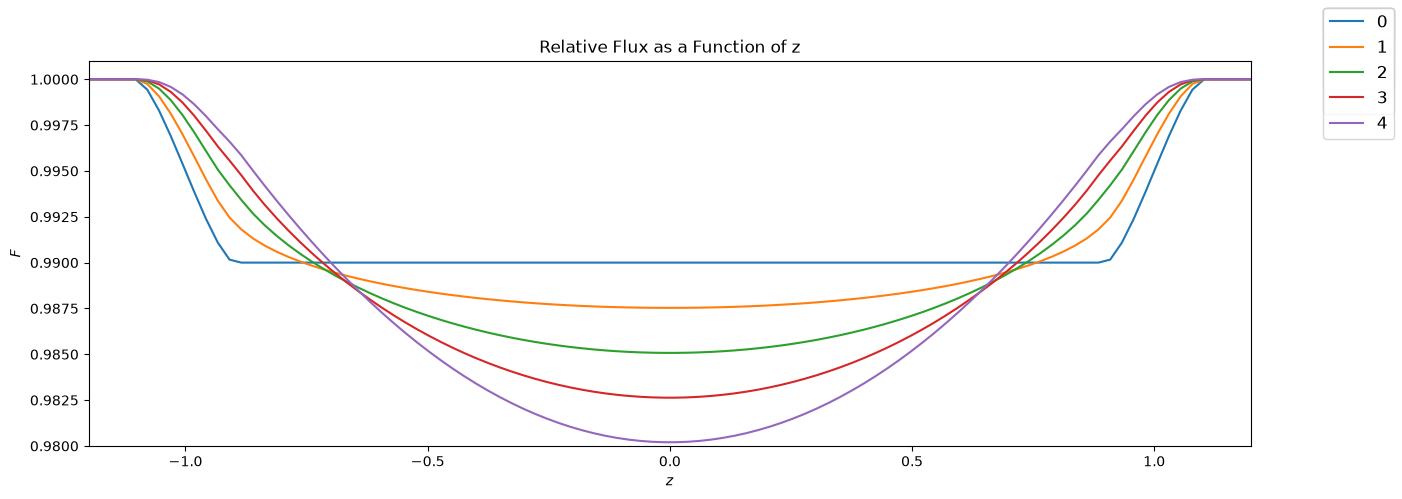

In [3]:
# Explore how nonlinear limb-darkening coefficients affect the modeled transit profile

# Test cases isolating each nonlinear limb-darkening coefficient
cmat = np.eye(5)

# Normalized separation values spanning the transit geometry
z = np.linspace(-1.2, 1.2, 100)

# Plot the relative-flux response for each limb-darkening case
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([0.980, 1.001])
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$F$')
ax.set_title('Relative Flux as a Function of z')
for b in range(len(cmat)):
    carr = cmat[b]
    G = []
    for a in z:
        f = MandelModel(0.1,a,carr)
        G.append(f)
    ax.plot(z, G, label = b)
    fig.legend(fontsize=12)

<Figure size 640x480 with 0 Axes>

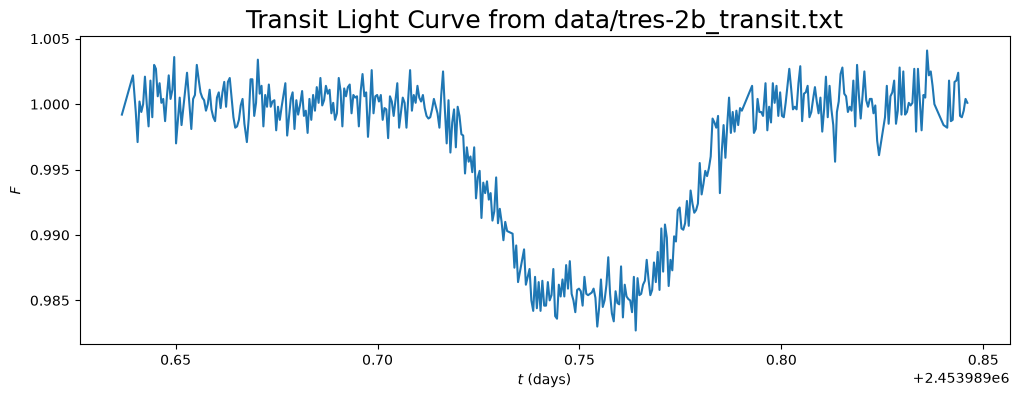

In [4]:
#Plotting raw data: relative flux vs time, this function also returns relative flux, time and uncertainty, sigma.
def read_transit(file='data/tres-2b_transit.txt', plot='y', display='n'):
    """
    Function read_transit reads a light curve file downloaded from the NASA Exoplanet Archive in the
    IPAC Table Format and returns light curve data in a 2D array with three columns:
    1. Heliocentric Julian Day
    2. Relative Flux
    3. Relative Flux Uncertainty
    
    Arguments to read_transit include:
    file - filename of the light curve in IPAC Table Format
    display - if 'y' the data in the IPAC Table is printed (not just the 3 columns), otherwise not printed
    plot - if 'y' the light curve is plotted, otherwise no plot
    
    The IPAC Table Format has keyword and comment rows that begin with "\"
    followed by header rows beginning with "|"
    followed by data in columns separated by whitespace.
    Different files may contain different numbers of columns in different order with different interpretation.
    For example, some files contain relative flux and some contain magnitude.
    Unfortunately, this means each light curve file must be examined and this function may need to be changed
    to return the appropriate data.
    
    The light curves used in Holman et al. 2007 which we are interested in have 4 columns in the following order:
    1. Heliocentric Julian Day
    2. Relative Flux
    3. Relative Flux Uncertainty
    4. Accepted
    
    The light curve IPAC Tables for Holman all have the data starting after row 137.
    Other light curve files will likely have the data starting on a different row, so skiprows=137 below will
    likely need to change.
    
    """
    try:
        light_curve = np.loadtxt(file, skiprows=137) # adjust for different files
    except:
        print(f'Unable to read light curve from {file}.')
    assert len(light_curve.shape) == 2, (
        f'The Light curve from {file} should be a 2D array, not shape {light_curve.shape}')
    assert light_curve.shape[1] == 4, ( # adjust for different files
        f'Light curve has {light_curve.shape[1]} columns.  Which columns are Day, Flux, and Uncertainty?')
    if display == 'y':
        print(f'Data from {file}:')
        print(light_curve)
    if plot == 'y':
        plt.figure()
        plt.figure(figsize=(12,4))
        plt.title(f'Transit Light Curve from {file}', fontsize=18)
        plt.xlabel(r'$t$ (days)')
        plt.ylabel(r'$F$')
        plt.plot(light_curve[:,0],light_curve[:,1]) # adjust for different files
    return light_curve[:, 0:3] # adjust for different files
data = read_transit(file='data/tres-2b_transit.txt')

In [5]:
# Numerically evaluated light-curve model
# This implementation uses numerical integration rather than symbolic integration,
# allowing the model to run efficiently during repeated optimization and MCMC evaluations.
def calcF(fitP, inP):
    ar = fitP[0]
    p = fitP[1]
    i = fitP[2]
    c1 = fitP[3]
    c2 = fitP[4]
    t = inP[0]
    w = inP[1]
    c3 = inP[2]
    c4 = inP[3]
    c0 = 1-c1-c2-c3-c4
    carr = [c0, c1, c2, c3, c4]
    z = (ar)*(np.sin(w*t)**2+(np.cos(i)*np.cos(w*t))**2)**(1/2)
    zz = np.abs(z)
    Omega = np.sum(carr/(4.0+np.arange(len(carr))))
    if zz<1.0-p:
        fac = p**2
        narr = np.arange(len(carr))
        rlo = zz-p #lower limit
        Ilo = rlo**2 + 4.0*(1.0-rlo**2)**(1.0+0.25*narr)/(4.0+narr) #integral at lower limit
        rhi = zz+p #upper limit
        Ihi = rhi**2 + 4.0*(1.0-rhi**2)**(1.0+0.25*narr)/(4.0+narr) #integral at upper limit
        Istar = rhi**2 - rlo**2 - np.sum(carr*(Ihi-Ilo)) #limit version of integral
        Istar /= 4.0*zz*p 
    elif zz<1.0+p:
        fac = p**2*np.arccos((zz-1.0)/p) - (zz-1.0)*np.sqrt(p**2-(zz-1.0)**2)
        fac = fac/np.pi  # it seems the Mandel & Agol paper missed a factor of pi
        narr = np.arange(len(carr))
        rlo = zz-p
        Ilo = rlo**2 + 4.0*(1.0-rlo**2)**(1.0+0.25*narr)/(4.0+narr)
        rhi = 1.0
        Ihi = rhi**2 + 4.0*(1.0-rhi**2)**(1.0+0.25*narr)/(4.0+narr)
        Istar = rhi**2 - rlo**2 - np.sum(carr*(Ihi-Ilo))
        Istar /= 1.0-(zz-p)**2
    else:
        fac = 0.0
        Istar = 0.0
    ans = 1.0 - fac*Istar/(4.0*Omega)
    return ans

def calc_lcrv(fitP, inP):
    ans = np.zeros(len(inP))
    for i in range(len(inP)):
        inP1 = inP[i]
        ans[i] = calcF(fitP, inP1)
    return ans

<Figure size 640x480 with 0 Axes>

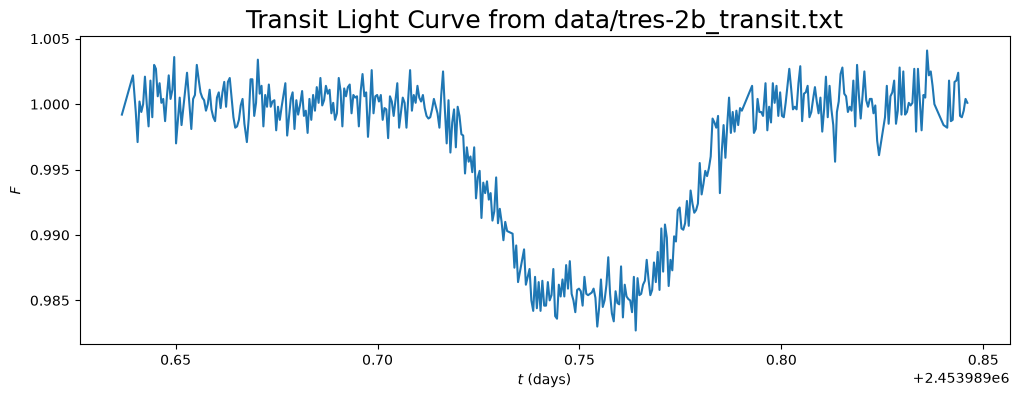

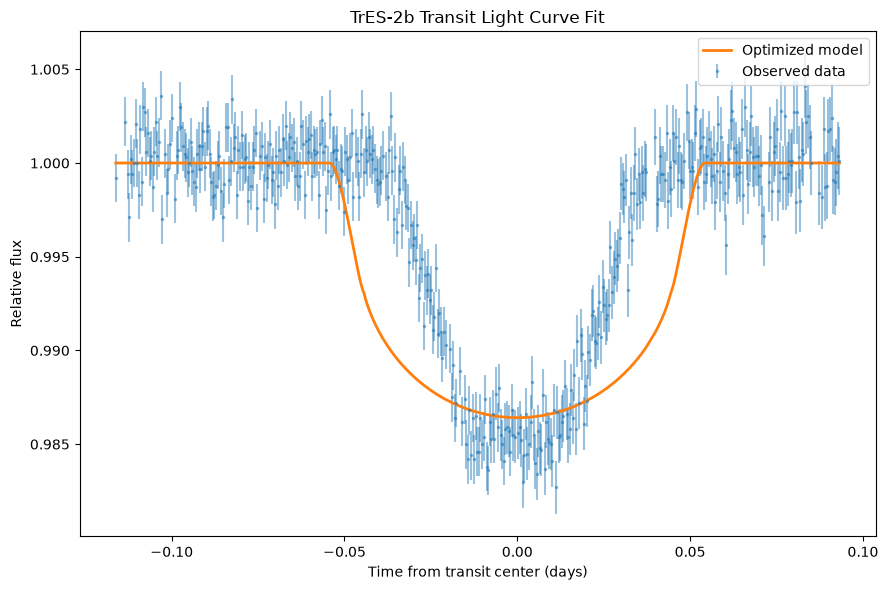

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 435.6271930509167
        x: [ 8.512e+00  1.214e-01  1.486e+00  2.402e-01  1.000e+00]
      nit: 78
      jac: [ 1.627e+01 -1.316e+02 -2.737e+02  2.748e+00  8.087e+00]
     nfev: 1176
     njev: 196
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


In [6]:
# Chi-square optimization for TrES-2b
# The model parameters are optimized by minimizing the chi-square statistic
# between the observed transit data and the theoretical light-curve model.

# Read observed transit data
light_curve = read_transit(file='data/tres-2b_transit.txt', plot='y', display='n')

# Time relative to the center of transit
t = light_curve[:,0] - 2453989.75286

# Orbital angular frequency
w = 2*np.pi/(2.47063)

# Higher-order nonlinear limb-darkening coefficients held fixed
c3 = 0
c4 = 0

# Create model input array
inP = []
for k in range(len(t)):
    inP.append([t[k], w, c3, c4])

# Initial parameter estimates
inc = np.pi/2
fitGuess = [8, 0.1, inc, 0.5, 0.5]

# Observed relative flux and measurement uncertainty
lcrvData = light_curve[:,1]
sigma = light_curve[:,2]

# Evaluate the model using the initial parameter estimates
lcrvModel = calc_lcrv(fitGuess, inP)

# Plot the model generated from the initial parameter estimates
plt.figure(figsize=(9,6))

plt.errorbar(
    t,
    lcrvData,
    yerr=sigma,
    fmt='.',
    alpha=0.45,
    markersize=3,
    label='Observed data'
)

plt.plot(
    t,
    lcrvModel,
    linewidth=2,
    label='Optimized model'
)

plt.xlabel('Time from transit center (days)')
plt.ylabel('Relative flux')
plt.title('TrES-2b Transit Light Curve Fit')
plt.legend()
plt.tight_layout()

plt.savefig(
    'figures/tres2b_lightcurve_fit.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

def Chi2Min(fitGuess, inP, lcrvData, sigma):

    # Reject non-physical parameter values before evaluating the model
    if (
        fitGuess[0] <= 0 or
        fitGuess[1] <= 0 or fitGuess[1] >= 1 or
        fitGuess[2] <= 0 or
        fitGuess[3] < 0 or fitGuess[3] > 1 or
        fitGuess[4] < 0 or fitGuess[4] > 1
    ):
        return 1e8

    lcrvModel = calc_lcrv(fitGuess, inP)

    chi2 = np.sum(((lcrvData - lcrvModel) / sigma) ** 2)

    return chi2

# Physically motivated parameter bounds used to prevent invalid model evaluations
bounds = [
    (0.01, None),        # a/R*
    (0.001, 0.999),      # planet/star radius ratio p
    (0.01, np.pi / 2),   # inclination
    (0.0, 1.0),          # c1
    (0.0, 1.0)           # c2
]

# Minimize chi-square using a bounded L-BFGS-B optimization
pBest = optimize.minimize(
    Chi2Min,
    fitGuess,
    args=(inP, lcrvData, sigma),
    method='L-BFGS-B',
    bounds=bounds
)
print(pBest)

C:\Users\acdem\AppData\Local\Temp\ipykernel_4828\2025249490.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


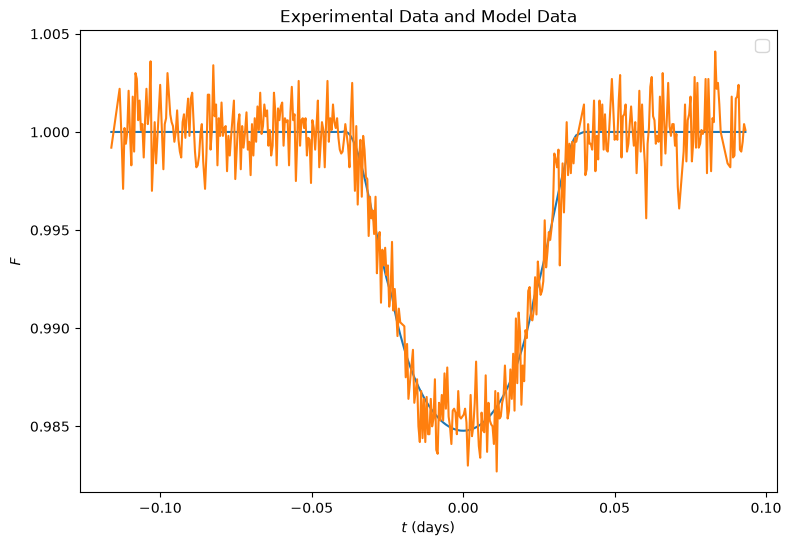

burn-in run
main run


C:\Users\acdem\AppData\Local\Temp\ipykernel_4828\2025249490.py:109: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
C:\Users\acdem\AppData\Local\Temp\ipykernel_4828\2025249490.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


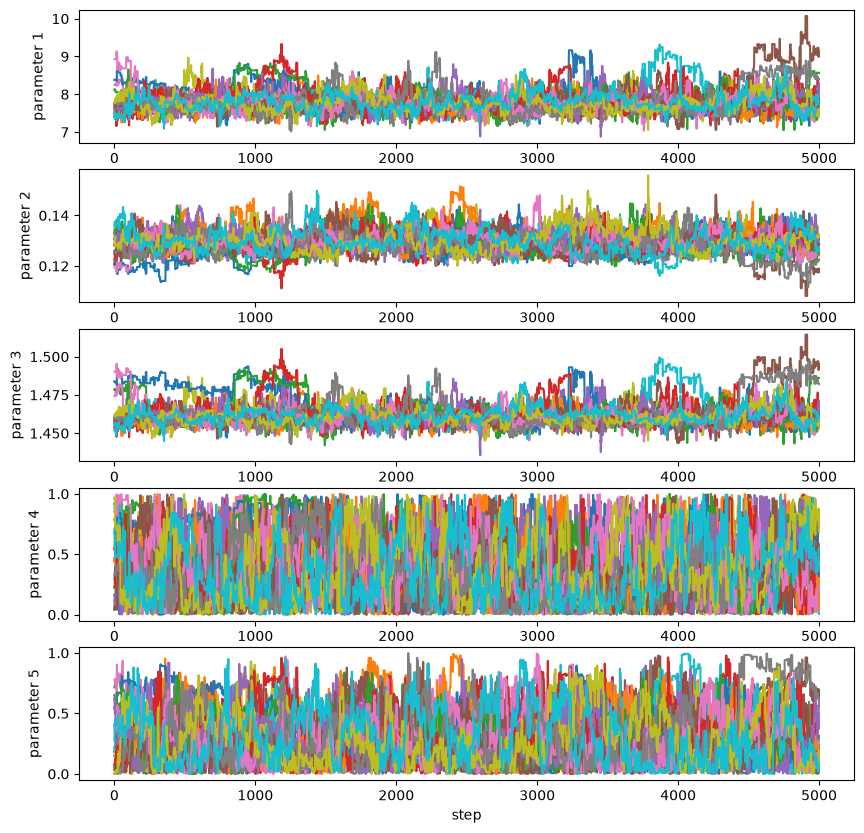

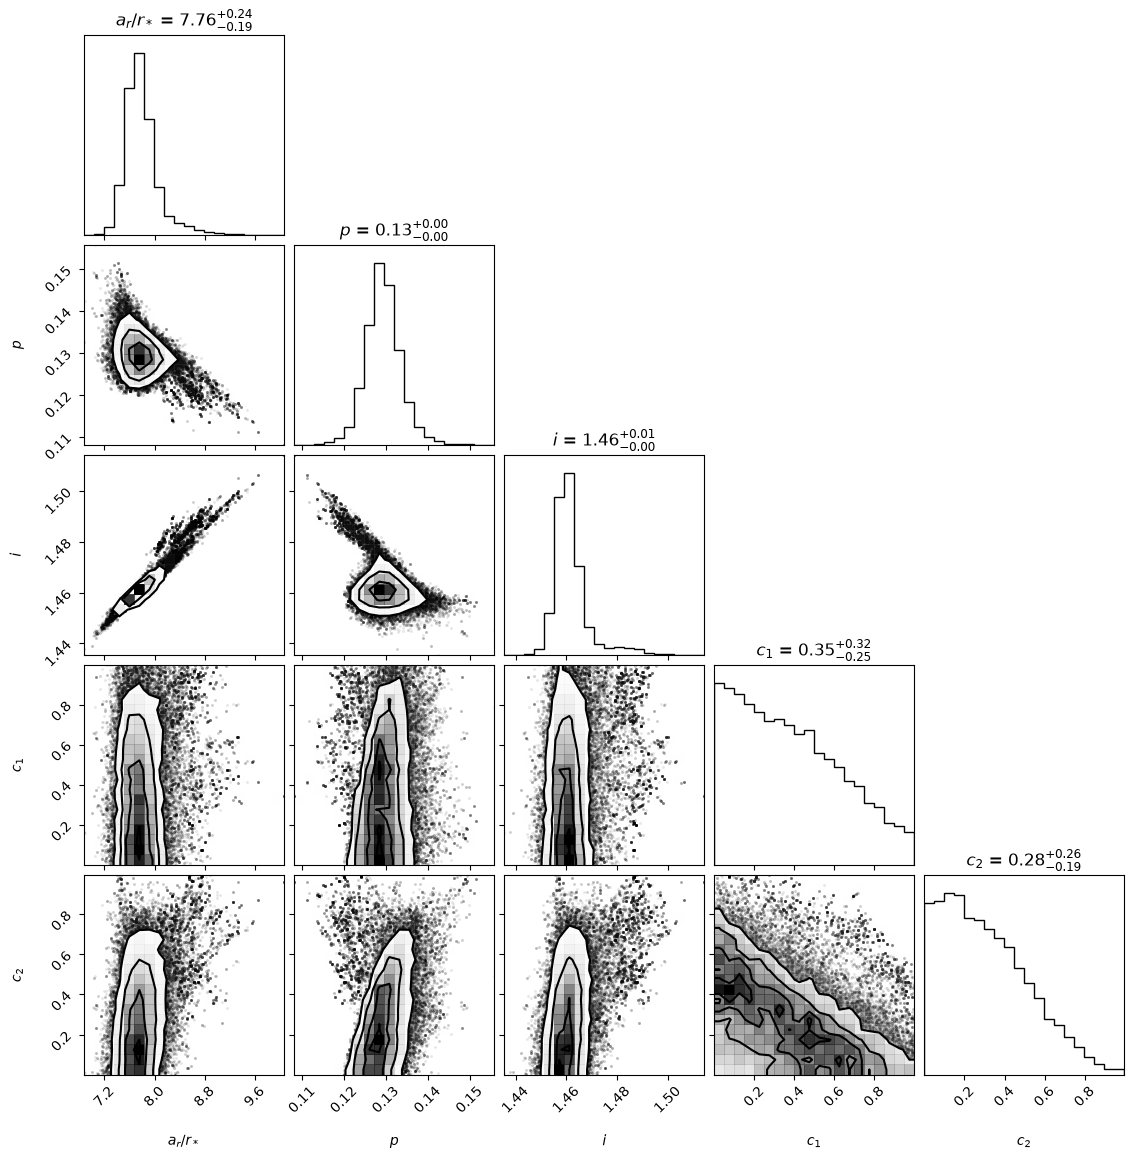

In [7]:
# Markov Chain Monte Carlo analysis using emcee
# MCMC sampling is used to estimate the posterior distributions and uncertainties
# of the optimized model parameters.
ndim = 5      # Number of fitted parameters
nwalk = 20    # Number of MCMC walkers
nburn = 1000  # Burn-in steps
nmain = 5000  # Production steps

# Calculate the relative-flux model using the optimized parameters
lcrvModel = calc_lcrv(pBest.x, inP)

# Compare the optimized model with the observed transit data
plt.figure(figsize=(9,6))
plt.plot(t,lcrvModel)
plt.plot(t,lcrvData)
plt.legend(fontsize=12)
plt.xlabel(r'$t$ (days)')
plt.ylabel(r'$F$')
plt.title('Experimental Data and Model Data')
plt.show()

# Define the log-probability function from the chi-square statistic
def lnprob(fitGuess, inP, lcrvData, sigma):

    # Reject non-physical parameter values
    if (
        fitGuess[0] <= 0 or
        fitGuess[1] <= 0 or fitGuess[1] >= 1 or
        fitGuess[2] <= 0 or fitGuess[2] > np.pi / 2 or
        fitGuess[3] < 0 or fitGuess[3] > 1 or
        fitGuess[4] < 0 or fitGuess[4] > 1
    ):
        return -np.inf

    lcrvModel = calc_lcrv(fitGuess, inP)

    # Reject any model evaluation that produces invalid values
    if not np.all(np.isfinite(lcrvModel)):
        return -np.inf

    chi2 = np.sum(((lcrvData - lcrvModel) / sigma) ** 2)

    return -0.5 * chi2

# Initialize walkers around the optimized solution
# using parameter-specific perturbations
np.random.seed(42)

pstart = pBest.x.copy()

# Move parameters that landed exactly on a boundary slightly inward
pstart[1] = np.clip(pstart[1], 0.005, 0.995)
pstart[2] = np.clip(pstart[2], 0.02, np.pi/2 - 0.02)
pstart[3] = np.clip(pstart[3], 0.02, 0.98)
pstart[4] = np.clip(pstart[4], 0.02, 0.98)

scales = np.array([
    0.10,   # a/R*
    0.005,  # radius ratio
    0.005,  # inclination
    0.02,   # c1
    0.02    # c2
])

p0 = []

while len(p0) < nwalk:
    candidate = pstart + scales * np.random.randn(ndim)

    if (
        candidate[0] > 0 and
        0 < candidate[1] < 1 and
        0 < candidate[2] <= np.pi/2 and
        0 <= candidate[3] <= 1 and
        0 <= candidate[4] <= 1
    ):
        p0.append(candidate)

p0 = np.array(p0)

# Create the ensemble sampler
sampler = emcee.EnsembleSampler(
    nwalk,
    ndim,
    lnprob,
    args=(inP, lcrvData, sigma)
)

# Run burn-in sampling
print('burn-in run')
state = sampler.run_mcmc(p0, nburn)

# Discard burn-in samples before the production run
sampler.reset()

# Run production sampling from the final burn-in state
print('main run')
sampler.run_mcmc(state, nmain)

samples = sampler.get_chain(flat=True)

# Plot MCMC traces for each fitted parameter
f,ax = plt.subplots(ndim,1,figsize=(10,10))
for idim in range(ndim):
    for iwalk in range(nwalk):
        ax[idim].plot(sampler.chain[iwalk,:,idim])
    ax[idim].set_xlabel('step')
    ax[idim].set_ylabel('parameter {}'.format(idim+1))
f.show()
# Visualize posterior distributions and parameter correlations
f = corner.corner(samples,show_titles=True,labels=('$a_r/r_*$','$p$','$i$','$c_1$','$c_2$'))
f.show()

<Figure size 640x480 with 0 Axes>

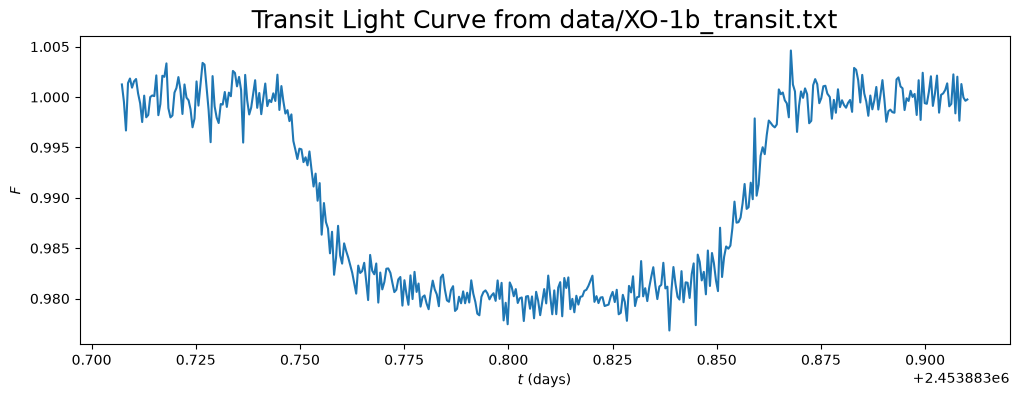

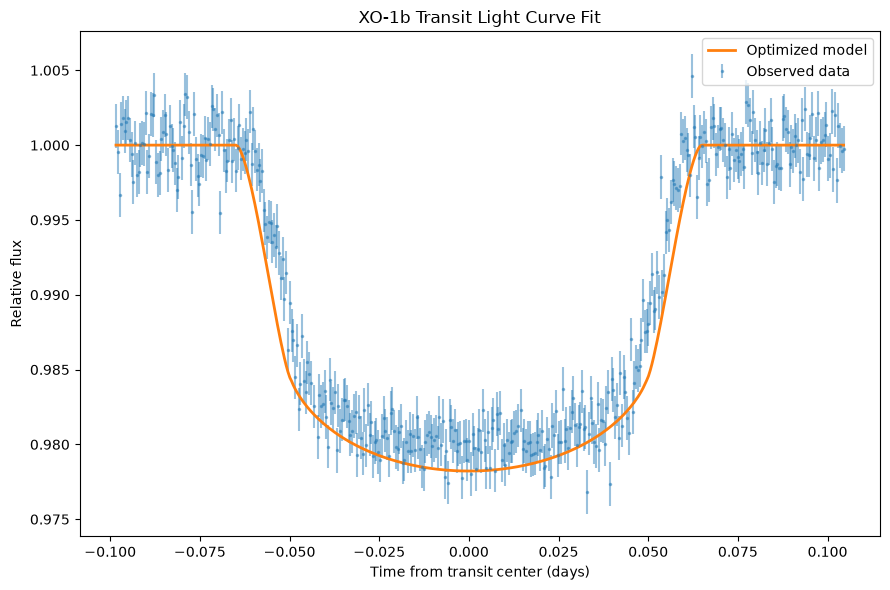

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 410.80871096457133
        x: [ 1.075e+01  1.355e-01  1.532e+00  5.704e-01  0.000e+00]
      nit: 50
      jac: [-2.046e-04  7.105e-04  3.809e-04 -2.501e-04  7.802e-01]
     nfev: 414
     njev: 69
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


In [8]:
# Repeat the fitting and uncertainty analysis for XO-1b
# Chi-square optimization for XO-1b

# Read observed transit data
light_curve = read_transit(file='data/XO-1b_transit.txt', plot='y', display='n')
# Time relative to the center of transit
t = light_curve[:,0] - 2453883.80565
# Orbital angular frequency
w = 2*np.pi/(3.941534)
# Higher-order nonlinear limb-darkening coefficients held fixed
c3 = 0
c4 = 0

# Create model input array
inP = []
for k in range(len(t)):
    inP.append([t[k], w, c3, c4])

# Initial parameter estimates
inc = np.pi/2
fitGuess = [11, 0.135, inc, 0.5, 0.2] 

# Observed relative flux and measurement uncertainty
lcrvData = light_curve[:,1]
sigma = light_curve[:,2]

# Evaluate the model using the initial parameter estimates
lcrvModel = calc_lcrv(fitGuess, inP)

# Plot the model generated from the initial parameter estimates
plt.figure(figsize=(9,6))

plt.errorbar(
    t,
    lcrvData,
    yerr=sigma,
    fmt='.',
    alpha=0.45,
    markersize=3,
    label='Observed data'
)

plt.plot(
    t,
    lcrvModel,
    linewidth=2,
    label='Optimized model'
)

plt.xlabel('Time from transit center (days)')
plt.ylabel('Relative flux')
plt.title('XO-1b Transit Light Curve Fit')
plt.legend()
plt.tight_layout()

plt.savefig(
    'figures/xo1b_lightcurve_fit.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

def Chi2Min(fitGuess, inP, lcrvData, sigma):

    # Reject non-physical parameter values before evaluating the model
    if (
        fitGuess[0] <= 0 or
        fitGuess[1] <= 0 or fitGuess[1] >= 1 or
        fitGuess[2] <= 0 or
        fitGuess[3] < 0 or fitGuess[3] > 1 or
        fitGuess[4] < 0 or fitGuess[4] > 1
    ):
        return 1e8

    lcrvModel = calc_lcrv(fitGuess, inP)

    chi2 = np.sum(((lcrvData - lcrvModel) / sigma) ** 2)

    return chi2

# Physically motivated parameter bounds used to prevent invalid model evaluations
bounds = [
    (0.01, None),        # a/R*
    (0.001, 0.999),      # planet/star radius ratio p
    (0.01, np.pi / 2),   # inclination
    (0.0, 1.0),          # c1
    (0.0, 1.0)           # c2
]

# Minimize chi-square using a bounded L-BFGS-B optimization
pBest = optimize.minimize(
    Chi2Min,
    fitGuess,
    args=(inP, lcrvData, sigma),
    method='L-BFGS-B',
    bounds=bounds
)
print(pBest)

C:\Users\acdem\AppData\Local\Temp\ipykernel_4828\3984501718.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


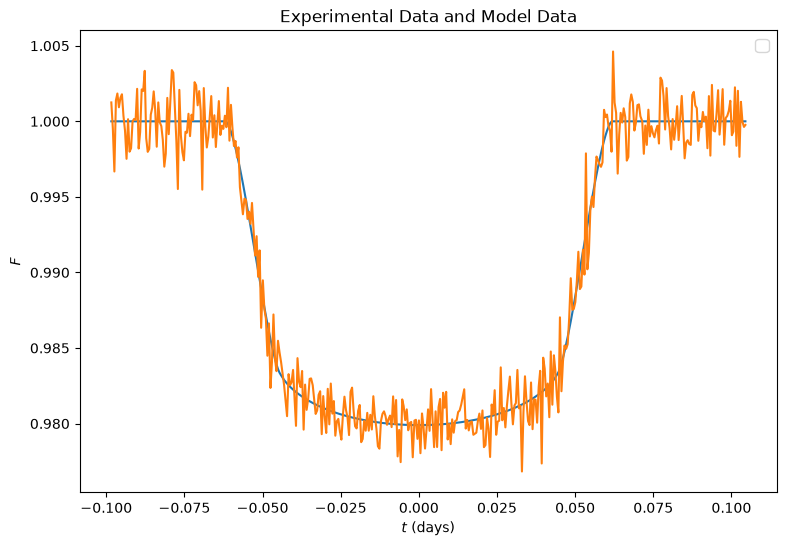

burn-in run
main run


C:\Users\acdem\AppData\Local\Temp\ipykernel_4828\3984501718.py:111: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
C:\Users\acdem\AppData\Local\Temp\ipykernel_4828\3984501718.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


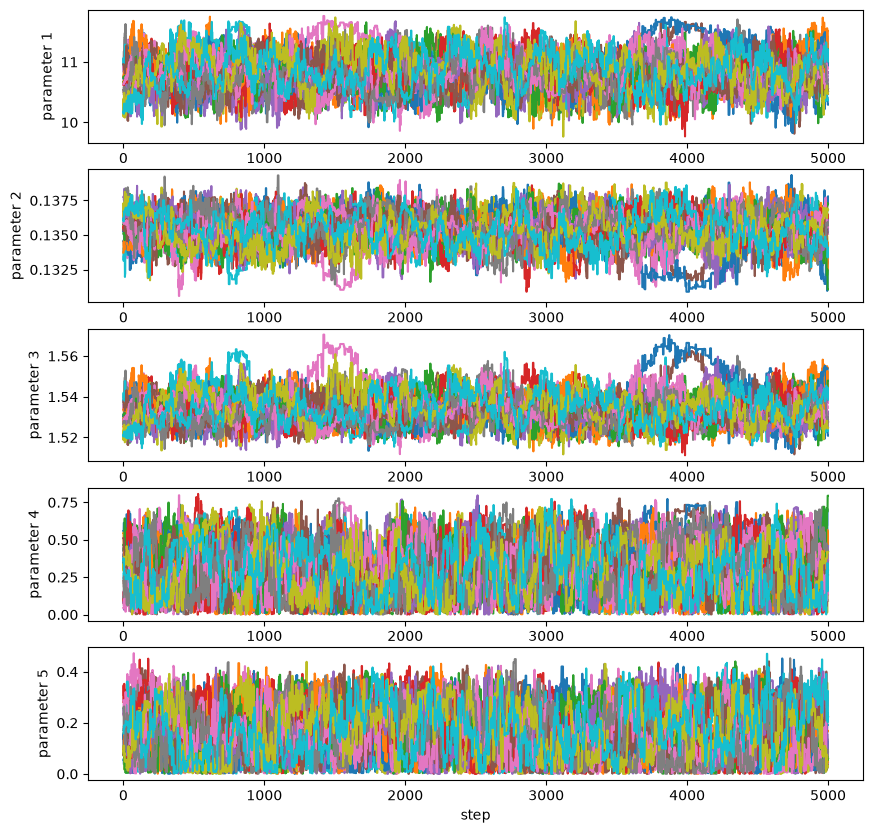

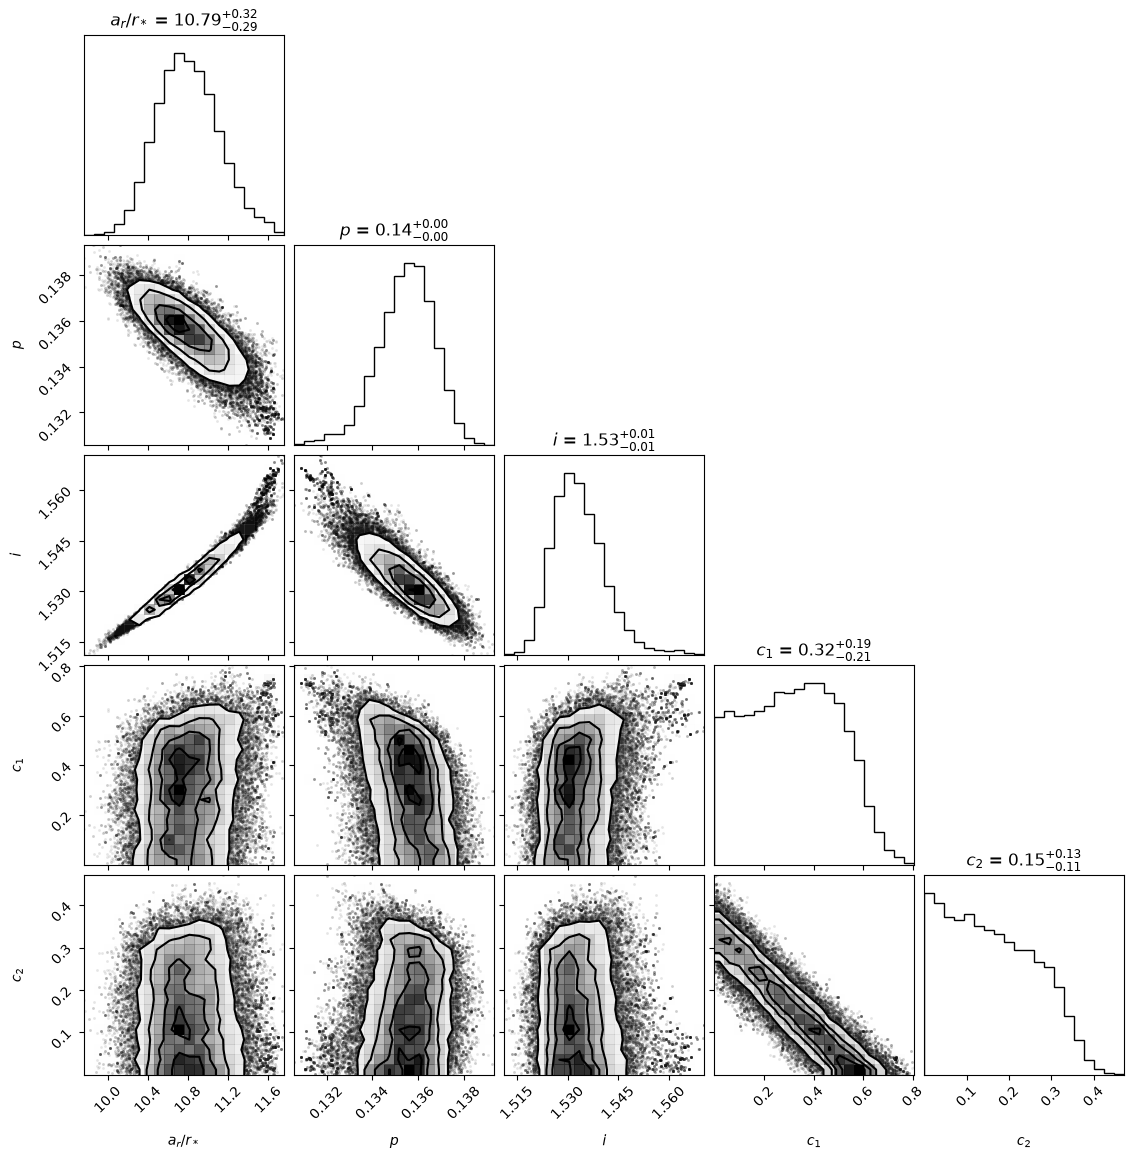

In [9]:
# Markov Chain Monte Carlo analysis using emcee
# MCMC sampling is used to estimate the posterior distributions and uncertainties
# of the optimized model parameters.
ndim = 5      # Number of fitted parameters
nwalk = 20    # Number of MCMC walkers
nburn = 1000  # Burn-in steps
nmain = 5000  # Production steps

# Calculate the relative-flux model using the optimized parameters
lcrvModel = calc_lcrv(pBest.x, inP)

# Compare the optimized model with the observed transit data
plt.figure(figsize=(9,6))
plt.plot(t,lcrvModel)
plt.plot(t,lcrvData)
plt.legend(fontsize=12)
plt.xlabel(r'$t$ (days)')
plt.ylabel(r'$F$')
plt.title('Experimental Data and Model Data')
plt.show()

# Define the log-probability function from the chi-square statistic
def lnprob(fitGuess, inP, lcrvData, sigma):

    # Reject non-physical parameter values
    if (
        fitGuess[0] <= 0 or
        fitGuess[1] <= 0 or fitGuess[1] >= 1 or
        fitGuess[2] <= 0 or fitGuess[2] > np.pi / 2 or
        fitGuess[3] < 0 or fitGuess[3] > 1 or
        fitGuess[4] < 0 or fitGuess[4] > 1
    ):
        return -np.inf

    lcrvModel = calc_lcrv(fitGuess, inP)

    # Reject any model evaluation that produces invalid values
    if not np.all(np.isfinite(lcrvModel)):
        return -np.inf

    chi2 = np.sum(((lcrvData - lcrvModel) / sigma) ** 2)

    return -0.5 * chi2

# Initialize walkers around the optimized solution
# using parameter-specific perturbations
np.random.seed(42)

pstart = pBest.x.copy()

# Move parameters that landed exactly on a boundary slightly inward
pstart[1] = np.clip(pstart[1], 0.005, 0.995)
pstart[2] = np.clip(pstart[2], 0.02, np.pi/2 - 0.02)
pstart[3] = np.clip(pstart[3], 0.02, 0.98)
pstart[4] = np.clip(pstart[4], 0.02, 0.98)

scales = np.array([
    0.10,   # a/R*
    0.005,  # radius ratio
    0.005,  # inclination
    0.02,   # c1
    0.02    # c2
])

p0 = []

while len(p0) < nwalk:
    candidate = pstart + scales * np.random.randn(ndim)

    if (
        candidate[0] > 0 and
        0 < candidate[1] < 1 and
        0 < candidate[2] <= np.pi/2 and
        0 <= candidate[3] <= 1 and
        0 <= candidate[4] <= 1
    ):
        p0.append(candidate)

p0 = np.array(p0)

# Create the ensemble sampler
sampler = emcee.EnsembleSampler(
    nwalk,
    ndim,
    lnprob,
    args=(inP, lcrvData, sigma)
)

# Run burn-in sampling
print('burn-in run')
state = sampler.run_mcmc(p0, nburn)

# Discard burn-in samples before the production run
sampler.reset()

# Run production sampling from the final burn-in state
print('main run')
sampler.run_mcmc(state, nmain)

samples = sampler.get_chain(flat=True)

# Plot MCMC traces for each fitted parameter
f,ax = plt.subplots(ndim,1,figsize=(10,10))
chain = sampler.get_chain()

for idim in range(ndim):
    for iwalk in range(nwalk):
        ax[idim].plot(chain[:, iwalk, idim])
    ax[idim].set_xlabel('step')
    ax[idim].set_ylabel('parameter {}'.format(idim+1))
f.show()
# Visualize posterior distributions and parameter correlations
f = corner.corner(samples,show_titles=True,labels=('$a_r/r_*$','$p$','$i$','$c_1$','$c_2$'))
f.show()